In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")


In [ ]:

#step2:

missing_count_before = df.isnull().sum().sum()
print(f"\nTotal missing values found: {missing_count_before}")
    
    # Drop rows with any missing values - The one-line hint

df_cleaned = df.dropna()
    
    # Update the reference to the cleaned DataFrame
df = df_cleaned
    
    # Verify the results
missing_count_after = df.isnull().sum().sum()
print(f"Total missing values after dropna(): {missing_count_after}")
print(f"DataFrame shape after cleaning: {df.shape}")
print("\nFirst 5 rows of the processed DataFrame:")
print(df.head())


Total missing values found: 569
Total missing values after dropna(): 0
DataFrame shape after cleaning: (0, 33)

First 5 rows of the processed DataFrame:
Empty DataFrame
Columns: [id, diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst, Unnamed: 32]
Index: []

[0 rows x 33 columns]


In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("data.csv")

# 'diagnosis' is your target (M/B)
target_column = "diagnosis"

# All numeric features = all columns except the target
numeric_features = df.drop(columns=[target_column]).columns

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print(df_scaled.head())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0 -0.236405         M     1.097064     -2.073335        1.269934   0.984375   
1 -0.236403         M     1.829821     -0.353632        1.685955   1.908708   
2  0.431741         M     1.579888      0.456187        1.566503   1.558884   
3  0.432121         M    -0.768909      0.253732       -0.592687  -0.764464   
4  0.432201         M     1.750297     -1.151816        1.776573   1.826229   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         1.568466          3.283515        2.652874             2.532475   
1        -0.826962         -0.487072       -0.023846             0.548144   
2         0.942210          1.052926        1.363478             2.037231   
3         3.283553          3.402909        1.915897             1.451707   
4         0.280372          0.539340        1.371011             1.428493   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

df = pd.read_csv("data.csv")

# -----------------------------
# 1. Encode the target column
# -----------------------------
target_column = "diagnosis"   # M/B

label_encoder = LabelEncoder()
df[target_column] = label_encoder.fit_transform(df[target_column])
# M → 1, B → 0  (default mapping)

# -----------------------------
# 2. Scaling all numeric features
# -----------------------------
numeric_features = df.drop(columns=[target_column]).columns

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print(df_scaled.head())


         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0 -0.236405          1     1.097064     -2.073335        1.269934   0.984375   
1 -0.236403          1     1.829821     -0.353632        1.685955   1.908708   
2  0.431741          1     1.579888      0.456187        1.566503   1.558884   
3  0.432121          1    -0.768909      0.253732       -0.592687  -0.764464   
4  0.432201          1     1.750297     -1.151816        1.776573   1.826229   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         1.568466          3.283515        2.652874             2.532475   
1        -0.826962         -0.487072       -0.023846             0.548144   
2         0.942210          1.052926        1.363478             2.037231   
3         3.283553          3.402909        1.915897             1.451707   
4         0.280372          0.539340        1.371011             1.428493   

   ...  texture_worst  perimeter_worst  area_worst  smoo

c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [22]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

# Load dataset
df = pd.read_csv("data.csv")

# ---------------------------------------
# 1. Handle NaN Values
#    - For numeric columns → fill with mean
#    - For diagnosis column → fill with mode
# ---------------------------------------
target_column = "diagnosis"

# Fill NaN in target with most frequent value (rare but safe)
df[target_column] = df[target_column].fillna(df[target_column].mode()[0])

# Fill NaN in numeric columns with mean
numeric_features = df.drop(columns=[target_column]).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].mean())

# ---------------------------------------
# 2. Encode the diagnosis column (M/B → 1/0)
# ---------------------------------------
label_encoder = LabelEncoder()
df[target_column] = label_encoder.fit_transform(df[target_column])

# ---------------------------------------
# 3. NORMALIZATION (Min-Max Scaling)
# ---------------------------------------
scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[numeric_features] = scaler.fit_transform(df[numeric_features])

# ---------------------------------------
# 4. Done — print result
# ---------------------------------------
print(df_normalized.head())


         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0  0.000915          1     0.521037      0.022658        0.545989   0.363733   
1  0.000915          1     0.643144      0.272574        0.615783   0.501591   
2  0.092495          1     0.601496      0.390260        0.595743   0.449417   
3  0.092547          1     0.210090      0.360839        0.233501   0.102906   
4  0.092559          1     0.629893      0.156578        0.630986   0.489290   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0         0.593753          0.792037        0.703140             0.731113   
1         0.289880          0.181768        0.203608             0.348757   
2         0.514309          0.431017        0.462512             0.635686   
3         0.811321          0.811361        0.565604             0.522863   
4         0.430351          0.347893        0.463918             0.518390   

   ...  texture_worst  perimeter_worst  area_worst  smoo

c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\Naz\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


C:\Users\Naz\AppData\Local\Temp\ipykernel_23032\1133584613.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['diagnosis_encoded'] = df_plot['diagnosis_encoded'].map({0: 'B', 1: 'M'})


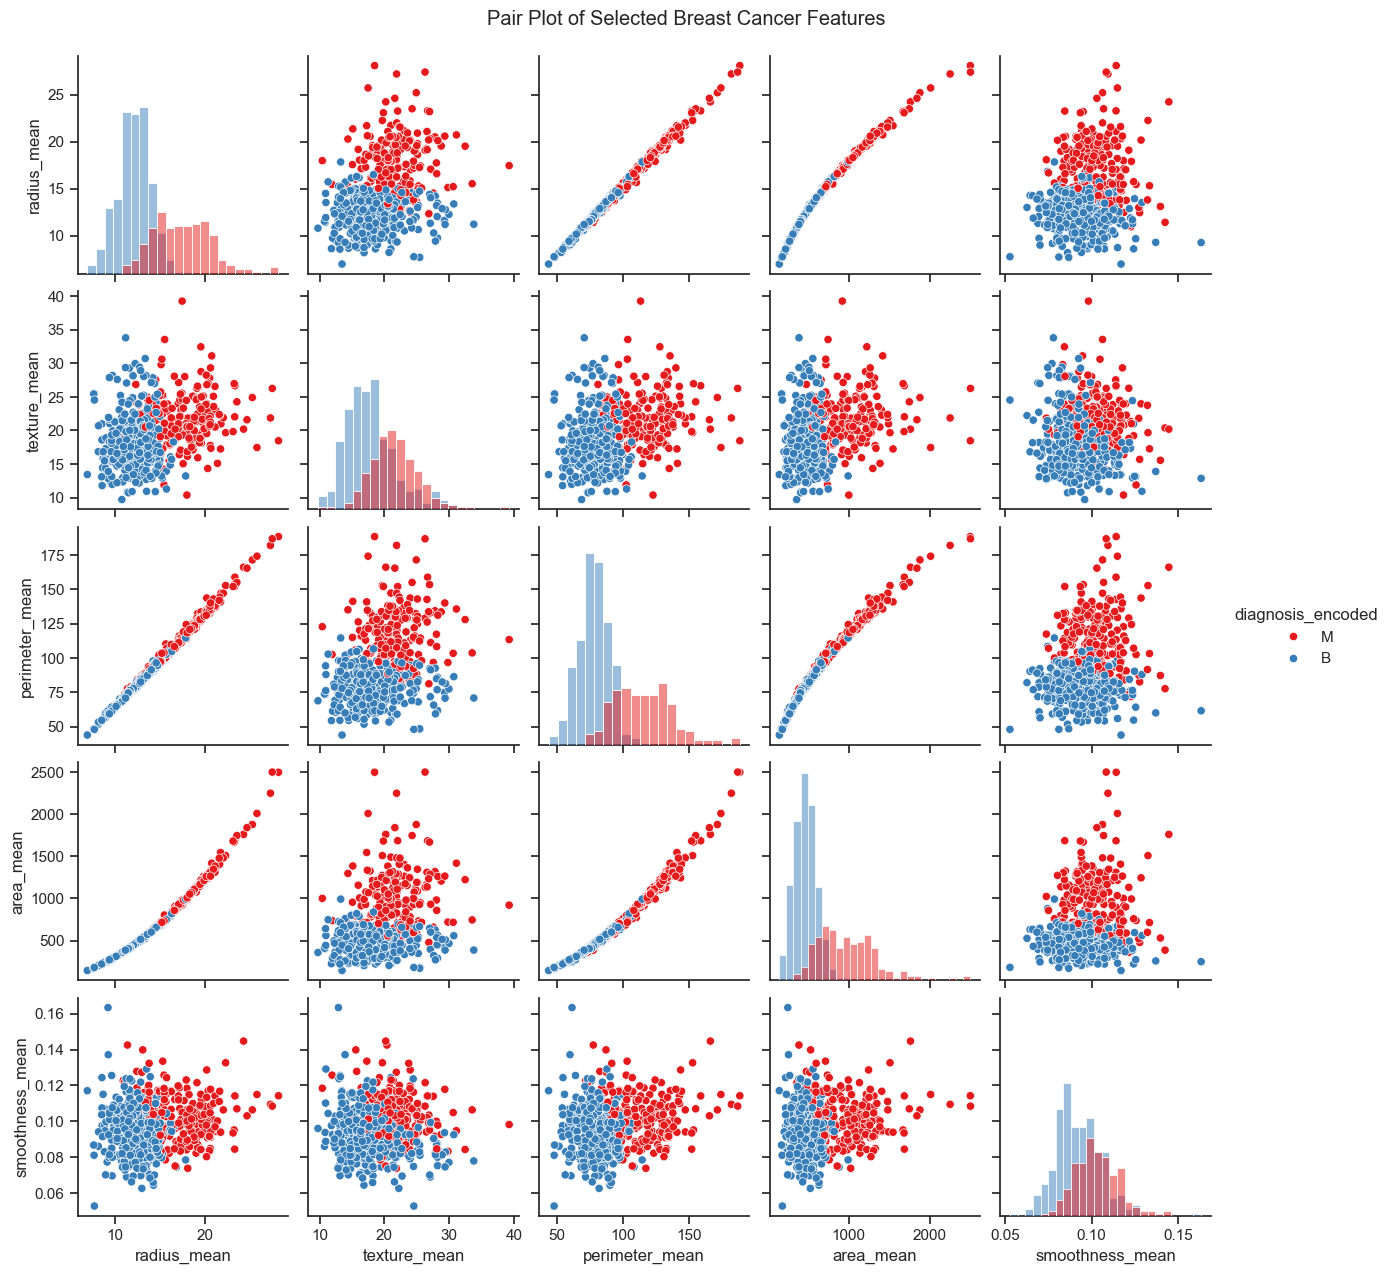

In [ ]:
#Step4 Prepare Visualization

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv")

# Encode target column for visualization (M → 1, B → 0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Optional: select a subset of numeric features for pair plot (too many will be cluttered)
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']

# Add target column to the subset
df_plot = df[features_to_plot + ['diagnosis_encoded']]

# Rename target for better readability in the plot
df_plot['diagnosis_encoded'] = df_plot['diagnosis_encoded'].map({0: 'B', 1: 'M'})

# Pair plot
sns.set(style="ticks")
pair_plot = sns.pairplot(df_plot, hue='diagnosis_encoded', palette='Set1', diag_kind='hist', corner=False)
pair_plot.fig.suptitle("Pair Plot of Selected Breast Cancer Features", y=1.02)

plt.show()


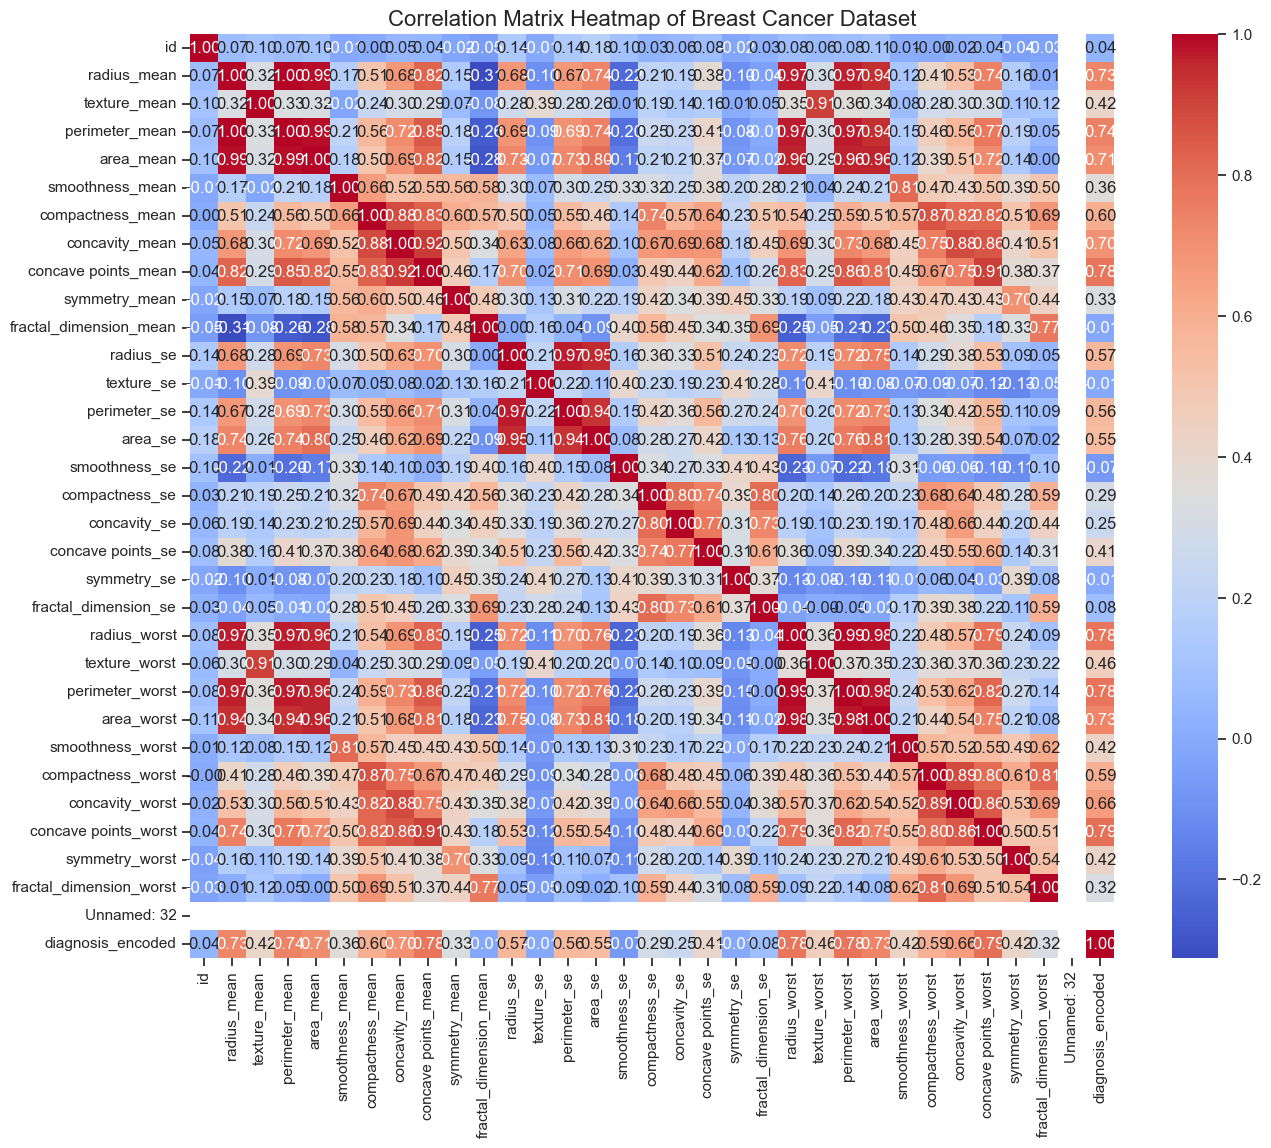

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("data.csv")

# Encode target column: M → 1, B → 0
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Select only numeric columns (exclude the original string 'diagnosis')
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix Heatmap of Breast Cancer Dataset", fontsize=16)
plt.show()


C:\Users\Naz\AppData\Local\Temp\ipykernel_23032\2842396061.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='Set2')
C:\Users\Naz\AppData\Local\Temp\ipykernel_23032\2842396061.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='Set2')
C:\Users\Naz\AppData\Local\Temp\ipykernel_23032\2842396061.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='Set2')
C:\Users\Naz\AppData\Local\Temp\ipykernel_23032\2842396061

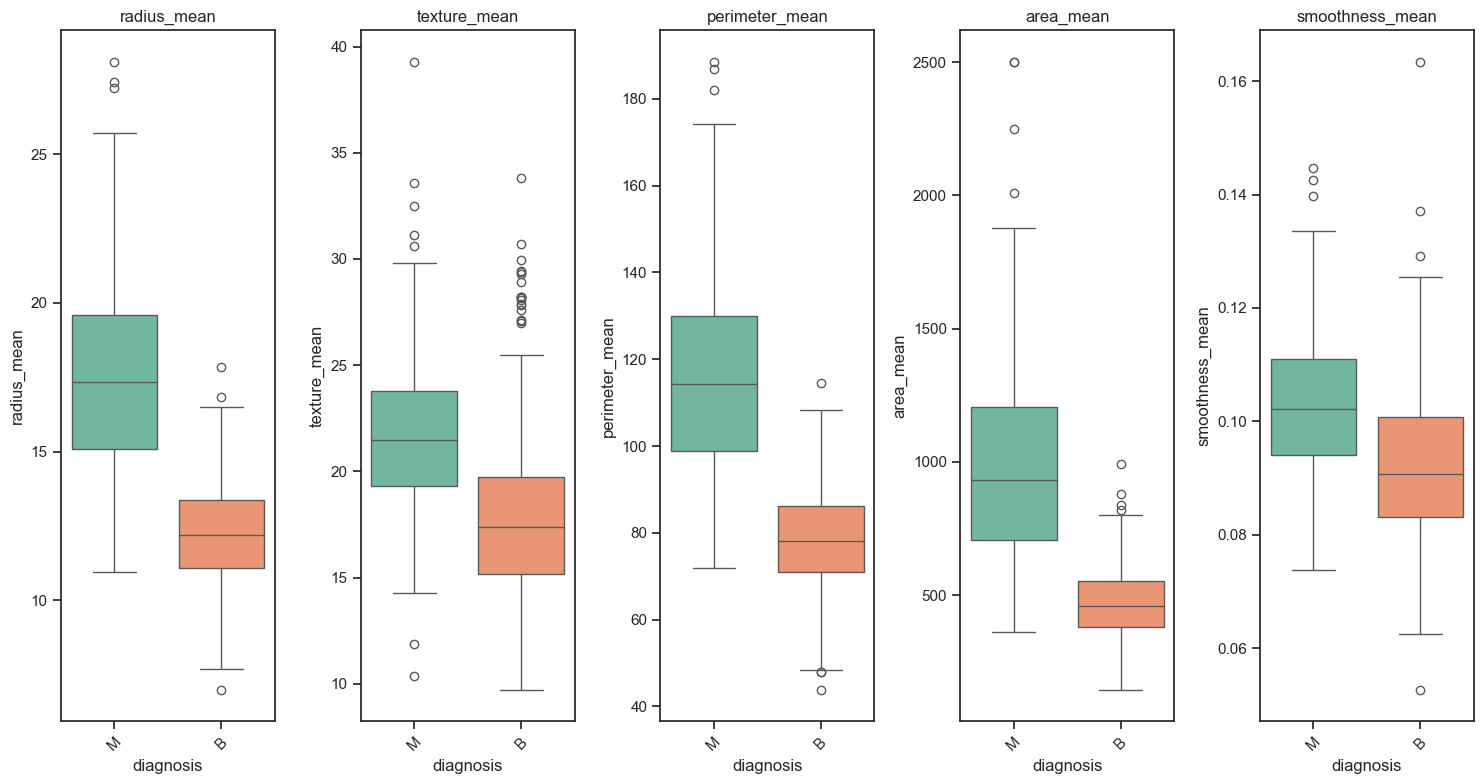

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv")

# Encode target column if needed (for coloring)
# M = Malignant, B = Benign
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# Optional: select a subset of numeric features to avoid clutter
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']

# Create box plots
plt.figure(figsize=(15, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, len(features_to_plot), i)
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='Set2')
    plt.title(feature)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [3]:
# Step 5 Split the Data
#Splitting the Data 80% training set.
#10% Validation set.
#10% test set.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data.csv")

# FIX: fill missing values instead of dropping everything
df = df.fillna(df.mean(numeric_only=True))

# Encode target column
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Define X and y
X = df.drop(['diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

# 80/10/10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 455
Validation set size: 57
Test set size: 57


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv("data.csv")

# Remove irrelevant columns
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode diagnosis column
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

df.head()

# Define X and y
X = df.drop(['diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print("Decision Tree MSE:", mse_dt)

# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest MSE:", mse_rf)
#print("SVR:", mse_svr)

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create pipeline (scaling + SVR)
svr = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10, epsilon=0.1)
)

# Train SVR
svr.fit(X_train, y_train)

# Predict
y_pred_svr = svr.predict(X_test)

# Compute MSE
mse_svr = mean_squared_error(y_test, y_pred_svr)

#print("SVR MSE:", mse_svr)

print("\n--- MODEL PERFORMANCE (MSE) ---")
print("Decision Tree:", mse_dt)
print("Random Forest:", mse_rf)
print("SVR:", mse_svr)



Decision Tree MSE: 0.05263157894736842
Random Forest MSE: 0.03256820175438596

--- MODEL PERFORMANCE (MSE) ---
Decision Tree: 0.05263157894736842
Random Forest: 0.03256820175438596
SVR: 0.04530976336855053


In [10]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data.csv").drop(columns=["id","Unnamed: 32"], errors="ignore")
df["diagnosis_encoded"] = LabelEncoder().fit_transform(df["diagnosis"])

X = df.drop(["diagnosis","diagnosis_encoded"], axis=1)
y = df["diagnosis_encoded"]


# ================================
# SPLIT
# ================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# MODELS
# ================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

dt = DecisionTreeRegressor().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200).fit(X_train, y_train)
svr = make_pipeline(StandardScaler(), SVR()).fit(X_train, y_train)

y_dt  = dt.predict(X_test)
y_rf  = rf.predict(X_test)
y_svr = svr.predict(X_test)


# ================================
# METRICS
# ================================
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def metrics(name, y_pred):
    print(f"{name}:  R2={r2_score(y_test,y_pred):.4f}, "
          f"MSE={mean_squared_error(y_test,y_pred):.4f}, "
          f"MAE={mean_absolute_error(y_test,y_pred):.4f}")

metrics("Decision Tree", y_dt)
metrics("Random Forest", y_rf)
metrics("SVR", y_svr)


Decision Tree:  R2=0.7760, MSE=0.0526, MAE=0.0526
Random Forest:  R2=0.8621, MSE=0.0324, MAE=0.0655
SVR:  R2=0.8496, MSE=0.0353, MAE=0.1276


In [11]:
#minimum r2 score of 82%.


# ============================
# LOAD + PREP
# ============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data.csv").drop(columns=["id","Unnamed: 32"], errors="ignore")
df["diagnosis_encoded"] = LabelEncoder().fit_transform(df["diagnosis"])
X = df.drop(["diagnosis","diagnosis_encoded"], axis=1)
y = df["diagnosis_encoded"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ============================
# MODELS
# ============================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

dt  = DecisionTreeRegressor().fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=350, max_depth=12).fit(X_train, y_train)
svr = make_pipeline(StandardScaler(), SVR(C=15)).fit(X_train, y_train)

preds = {
    "Decision Tree": dt.predict(X_test),
    "Random Forest": rf.predict(X_test),
    "SVR": svr.predict(X_test)
}


# ============================
# METRICS + REQUIREMENT CHECK
# ============================
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

for name, y_pred in preds.items():
    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{name}: R2={r2:.4f}, MSE={mse:.4f}, MAE={mae:.4f}")
    print("✔ Meets requirement\n" if r2 >= 0.82 else "✘ Does NOT meet requirement\n")


Decision Tree: R2=0.7013, MSE=0.0702, MAE=0.0702
✘ Does NOT meet requirement

Random Forest: R2=0.8583, MSE=0.0333, MAE=0.0678
✔ Meets requirement

SVR: R2=0.7955, MSE=0.0480, MAE=0.1594
✘ Does NOT meet requirement



In [ ]:
#Compare the results of different models.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prepare data
df["diagnosis_encoded"] = LabelEncoder().fit_transform(df["diagnosis"])
X = df.drop(["diagnosis","diagnosis_encoded","id","Unnamed: 32"], axis=1, errors="ignore")
y = df["diagnosis_encoded"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=300),
    "SVR": make_pipeline(StandardScaler(), SVR())
}

# Train + evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = [
        r2_score(y_test, pred),
        mean_squared_error(y_test, pred),
        mean_absolute_error(y_test, pred)
    ]

# Print comparison
print("\n=== Model Comparison (R², MSE, MAE) ===")
for name, (r2, mse, mae) in results.items():
    print(f"{name}: R2={r2:.4f}, MSE={mse:.4f}, MAE={mae:.4f}")



=== Model Comparison (R², MSE, MAE) ===
Decision Tree: R2=0.7013, MSE=0.0702, MAE=0.0702
Random Forest: R2=0.8613, MSE=0.0326, MAE=0.0677
SVR: R2=0.8496, MSE=0.0353, MAE=0.1276
